In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import pearsonr

In [7]:
df = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\Data\merged_BBCA_sentiment_arima.csv")
df.head()

,Date,Close_x,High,Low,Open,Volume,SentimentScore,NumComments,HasComment,Close_y,Residual
0,2015-01-02,2171.209473,2179.418204,2158.896375,2179.418204,29302500,0.000000,0.0,0.0,2171.209473,2169.159272
1,2015-01-05,2167.105957,2167.105957,2154.792855,2158.897222,25434500,0.000000,0.0,0.0,2167.105957,-4.320405
2,2015-01-06,2150.688477,2167.105946,2134.271007,2134.271007,48681500,-0.500000,2.0,1.0,2150.688477,-17.869874
3,2015-01-07,2154.791992,2167.105089,2142.478895,2142.478895,40334000,-0.333333,3.0,1.0,2154.791992,-0.369493
4,2015-01-08,2130.166504,2158.897073,2130.166504,2154.792706,54457000,-0.200000,5.0,1.0,2130.166504,-27.901861


In [11]:
df = df.drop(df.index[0])
df.head(10)

,Date,Close_x,High,Low,Open,Volume,SentimentScore,NumComments,HasComment,Close_y,Residual
1,2015-01-05,2167.105957,2167.105957,2154.792855,2158.897222,25434500,0.000000,0.0,0.0,2167.105957,-4.320405
2,2015-01-06,2150.688477,2167.105946,2134.271007,2134.271007,48681500,-0.500000,2.0,1.0,2150.688477,-17.869874
3,2015-01-07,2154.791992,2167.105089,2142.478895,2142.478895,40334000,-0.333333,3.0,1.0,2154.791992,-0.369493
4,2015-01-08,2130.166504,2158.897073,2130.166504,2154.792706,54457000,-0.200000,5.0,1.0,2130.166504,-27.901861
5,2015-01-09,2121.956787,2146.582978,2121.956787,2138.374248,108957500,-0.333333,3.0,1.0,2121.956787,-13.667063
6,2015-01-12,2134.270508,2134.270508,2101.435577,2121.957409,81651000,1.000000,1.0,1.0,2134.270508,6.749880
7,2015-01-13,2134.270508,2142.479241,2130.166141,2142.479241,36024000,0.000000,1.0,1.0,2134.270508,-2.141245
8,2015-01-14,2121.956787,2138.374248,2121.956787,2138.374248,29728000,-0.200000,5.0,1.0,2121.956787,-14.174383
9,2015-01-15,2126.061279,2142.478741,2126.061279,2126.061279,27580500,0.166667,6.0,1.0,2126.061279,0.193205
10,2015-01-16,2126.061279,2138.374376,2126.061279,2138.374376,46354500,0.000000,0.0,0.0,2126.061279,-2.969984


In [13]:
df["Date"] = pd.to_datetime(df["Date"])

In [15]:
df = df.rename(columns={
    'Close_x': 'Close'
})

df = df.drop(['Close_y'], axis=1)

In [17]:
for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    df[col] = (
        df[col]
        .astype(str)                     # pastikan string
        .str.replace(',', '', regex=False)  # hapus koma ribuan
        .str.replace(' ', '', regex=False)  # hapus spasi
        .astype(float)                   # ubah ke float
    )

In [19]:
# --- 2️⃣ Tambahkan lag residual
# misal kamu mau 3 lag residual
for lag in range(1, 4):
    df[f'Residual_lag{lag}'] = df['Residual'].shift(lag)

# hapus baris NaN akibat shift
df = df.dropna().reset_index(drop=True)

In [21]:
# --- 3️⃣ Tentukan fitur dan target
features = ['Open', 'High', 'Low', 'Close', 'Volume',
            'Residual', 'Residual_lag1', 'Residual_lag2', 'Residual_lag3']
target_col = 'Close'
target_idx = features.index(target_col)


In [23]:
# --- 4️⃣ Split data train-test
split_ratio = 0.8
split = int(len(df) * split_ratio)
train_df = df.iloc[:split]
test_df = df.iloc[split:]

In [25]:
# --- 5️⃣ Scaling terpisah (hindari leakage)
scaler_main = MinMaxScaler()
scaler_resid = StandardScaler()

# fitur utama (Open–Volume)
scaled_main_train = scaler_main.fit_transform(train_df[['Open', 'High', 'Low', 'Close', 'Volume']])
scaled_main_test = scaler_main.transform(test_df[['Open', 'High', 'Low', 'Close', 'Volume']])

# fitur residual (Residual + lag)
resid_cols = ['Residual', 'Residual_lag1', 'Residual_lag2', 'Residual_lag3']
scaled_resid_train = scaler_resid.fit_transform(train_df[resid_cols])
scaled_resid_test = scaler_resid.transform(test_df[resid_cols])

# gabungkan main + residual
scaled_train = np.concatenate([scaled_main_train, scaled_resid_train], axis=1)
scaled_test = np.concatenate([scaled_main_test, scaled_resid_test], axis=1)

# gabung untuk sliding window (optional)
scaled_data = np.vstack([scaled_train, scaled_test])

In [27]:
# --- 4️⃣ Buat window time series (lookback 60)
lookback = 60
X, y = [], []
for i in range(lookback, len(scaled_data)):
    X.append(scaled_data[i-lookback:i])
    y.append(scaled_data[i, target_idx])

X, y = np.array(X), np.array(y)

In [29]:
# --- 5️⃣ Split ulang X/y sesuai proporsi train-test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target yang dipakai:", target_col)

X shape: (2589, 60, 9)
y shape: (2589,)
Target yang dipakai: Close


In [35]:
#Bangun Model LSTM

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dense(1)  # output 1 nilai Close
])

model.compile(optimizer='adam', loss='mse')
model.summary()

D:\Terminal\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 128)             │          70,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,433 (478.25 KB)

 Trainable params: 122,305 (477.75 KB)

 Non-trainable params: 128 (512.00 B)

In [36]:
#Latih Model 

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,     # berhenti jika 5 epoch berturut-turut val_loss tidak membaik
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.2537 - val_loss: 0.8641
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0951 - val_loss: 0.8578
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0605 - val_loss: 0.7140
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0468 - val_loss: 0.6610
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0395 - val_loss: 0.5873
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0324 - val_loss: 0.4859
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0267 - val_loss: 0.3219
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0229 - val_loss: 0.2506
Epoch 9/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0191 - val_loss: 0.2016
Epoch 10/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0172 - val_loss: 0.1392
Epoch 11/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0158 - val_loss: 0.1099
Epoch 12/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/ste

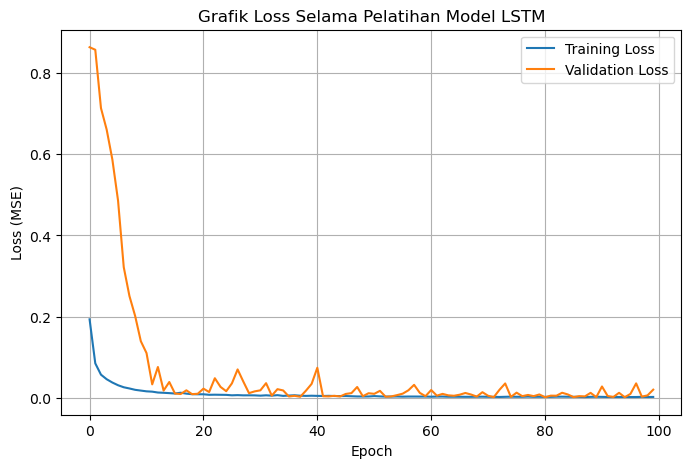

In [37]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss Selama Pelatihan Model LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
predictions = model.predict(X_test)

# --- inverse transform pakai scaler_main karena target = Close
y_test_full = np.zeros((len(y_test), 5))
y_pred_full = np.zeros((len(predictions), 5))

# isi hanya kolom ke-3 (Close)
y_test_full[:, 3] = y_test
y_pred_full[:, 3] = predictions[:, 0]

# inverse pakai scaler_main
y_test_inv = scaler_main.inverse_transform(y_test_full)[:, 3]
y_pred_inv = scaler_main.inverse_transform(y_pred_full)[:, 3]


17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step


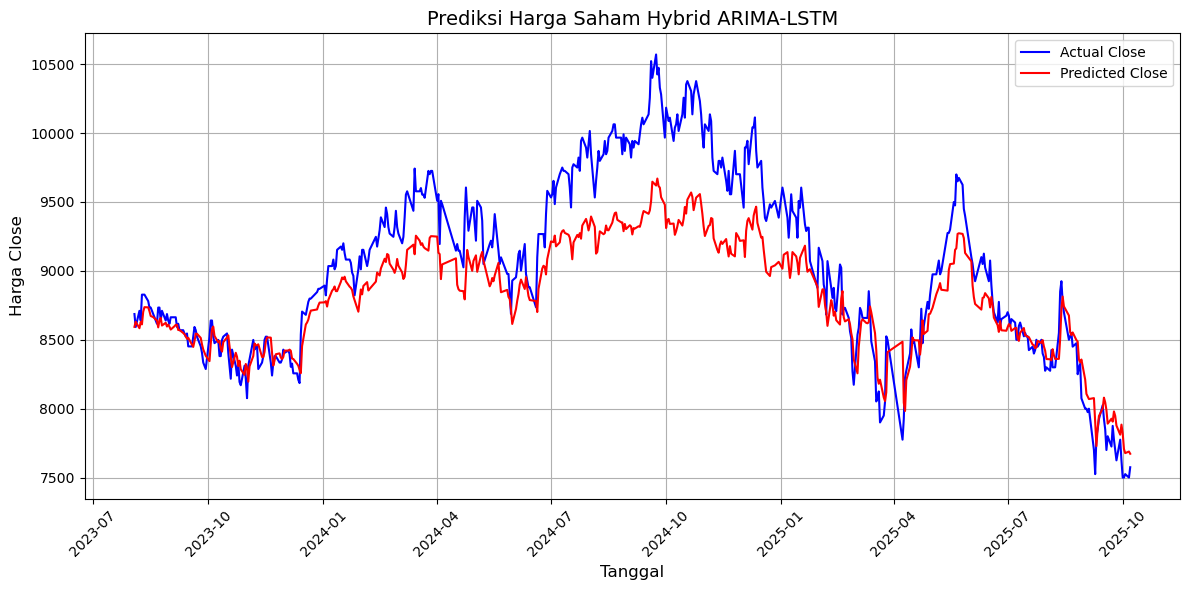

In [18]:
plt.figure(figsize=(12,6))

# Ambil tanggal yang sesuai dengan y_test
dates_test = df['Date'].iloc[-len(y_test_inv):]

plt.plot(dates_test, y_test_inv, label='Actual Close', color='blue')
plt.plot(dates_test, y_pred_inv, label='Predicted Close', color='red')

plt.title('Prediksi Harga Saham Hybrid ARIMA-LSTM', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga Close', fontsize=12)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [45]:
import pandas as pd

# Buat DataFrame untuk prediksi
df_pred = pd.DataFrame({
    'Date': dates_test,
    'Predicted_Close': y_pred_inv
})

# Simpan ke CSV
df_pred.to_csv('predicted_close_LSTM_ARIMA.csv', index=False)
print("CSV prediksi berhasil dibuat!")


CSV prediksi berhasil dibuat!


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# pastikan y_test_inv dan y_pred_inv adalah numpy array
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100
print(f"MAPE: {mape:.2f}%")

RMSE: 362.23
MAE: 275.95
MAPE: 2.92%


In [20]:
rmse_percent = (rmse / df['Close'].mean()) * 100
mae_percent = (mae / df['Close'].mean()) * 100
print(f"RMSE%: {rmse_percent:.2f}% | MAE%: {mae_percent:.2f}%")

RMSE%: 6.56% | MAE%: 5.00%


In [21]:
future_days = 30
lookback = 60  # pastikan sesuai
last_sequence = scaled_data[-lookback:]  # 60 data terakhir
future_predictions = []

current_seq = last_sequence.copy()

for _ in range(future_days):
    # prediksi Close
    pred_close = model.predict(current_seq.reshape(1, lookback, scaled_data.shape[1]))
    future_predictions.append(pred_close[0, 0])
    
    # buat row baru untuk geser window, pertahankan struktur 9 kolom
    next_row = current_seq[-1].copy()  # copy data terakhir
    next_row[3] = pred_close[0, 0]    # update Close
    # residual tetap dummy (misal ambil nilai terakhir atau bisa dihitung jika ada model residual)
    # next_row[5:9] tetap = current_seq[-1,5:9]
    
    # geser window
    current_seq = np.vstack([current_seq[1:], next_row])

# kembalikan ke skala asli untuk Close
future_full = np.zeros((len(future_predictions), scaled_data.shape[1]))
future_full[:, 3] = future_predictions  # hanya Close
future_pred_inv = scaler_main.inverse_transform(future_full[:, :5])[:, 3]  # Close asli


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━

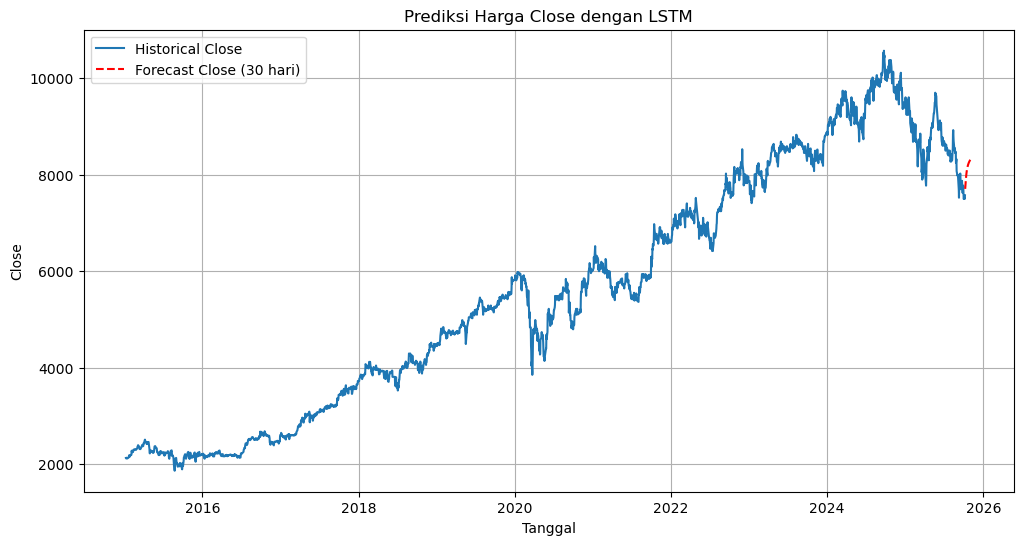

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# buat range tanggal untuk forecast
last_date = df['Date'].iloc[-1]  # tanggal terakhir historical
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=future_days)

# gabungkan historical + forecast untuk plotting
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Historical Close')
plt.plot(future_dates, future_pred_inv, label='Forecast Close (30 hari)', color='red', linestyle='--')
plt.title('Prediksi Harga Close dengan LSTM')
plt.xlabel('Tanggal')
plt.ylabel('Close')
plt.legend()
plt.grid(True)
plt.show()


In [47]:
lstm = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\predicted_close_LSTM.csv")
lstmsentimenarima = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\predicted_close_LSTM_AnalisisSentimen_ARIMA.csv")
lstmARIMA = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\predicted_close_LSTM_ARIMA.csv")
lstmsentimen = pd.read_csv(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\predicted_close_LSTM_sentimen.csv")

In [49]:
lstm.head()

,Date,Predicted_Close
0,2023-08-02,7904.013546
1,2023-08-03,7898.631575
2,2023-08-04,7903.818038
3,2023-08-07,7906.980316
4,2023-08-08,7914.240958


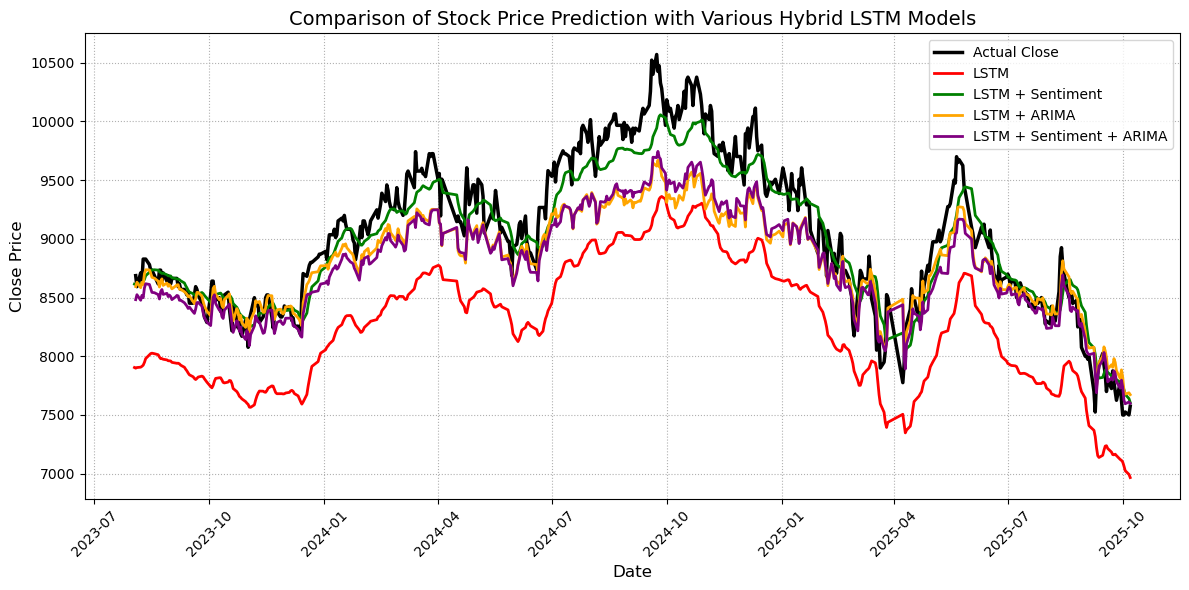

In [51]:
# --- 2. Pastikan kolom tanggal terbaca sebagai datetime ---
for df_pred in [lstm, lstmsentimenarima, lstmARIMA, lstmsentimen]:
    df_pred['Date'] = pd.to_datetime(df_pred['Date'])

# --- 3. Plot semua model pada satu grafik ---
plt.figure(figsize=(12,6))

# Data aktual
plt.plot(df['Date'].iloc[-len(y_test_inv):], y_test_inv, 
         label='Actual Close', color='black', linewidth=2.5)

# Hasil prediksi tiap model (garis tebal, warna berbeda)
plt.plot(lstm['Date'], lstm['Predicted_Close'], 
         label='LSTM', color='red', linewidth=2)
plt.plot(lstmsentimen['Date'], lstmsentimen['Predicted_Close'], 
         label='LSTM + Sentiment', color='green', linewidth=2)
plt.plot(lstmARIMA['Date'], lstmARIMA['Predicted_Close'], 
         label='LSTM + ARIMA', color='orange', linewidth=2)
plt.plot(lstmsentimenarima['Date'], lstmsentimenarima['Predicted_Close'], 
         label='LSTM + Sentiment + ARIMA', color='purple', linewidth=2)

# --- 4. Format tampilan ---
plt.title('Comparison of Stock Price Prediction with Various Hybrid LSTM Models', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()